# Facial Detection Backbone Evaluation Notebook
> Aston Lynch - 103964552

I have created this notebook after running into accuracy issues with the initial choice made for the actual detector backend. 

I wanted to use something that was lightweight, not causing more overhead (we are already running 3 models concurrently), and highly acccurate.

I also felt like this was a bit of a grey area for the assignment brief, which does not really mention if it's okay to use a fully-pretrained model for this purpose, however, since it is not really listed anywhere, and based off of discussions with my tutor, I believe using a pretrained model for this purpose is fine. 

This notebook will provide a documentable comparison that will justify the choice made for the model, outside of my own visual smoke-test. 

## 0 - Imports

In [1]:
import cv2
import numpy as np
import mediapipe as mp
import random
import time
import matplotlib.pyplot as plt
from pathlib import Path
import urllib.request
from mtcnn import MTCNN

I0000 00:00:1779847842.025847  211827 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779847842.054348  211827 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779847842.882478  211827 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
urllib.request.urlretrieve(
    "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite",
    "blaze_face_short_range.tflite"
)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt",
    "deploy.prototxt"
)
urllib.request.urlretrieve(
    "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel",
    "res10_ssd.caffemodel"
)
urllib.request.urlretrieve(
    "https://media.githubusercontent.com/media/opencv/opencv_zoo/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx",
    "yunet.onnx"
)

('yunet.onnx', <http.client.HTTPMessage at 0x7f9a014e5350>)

## 1 - Config

In [3]:
# Create subset of dataset for verification

IMAGE_DIR = Path("../data/dataset/verification_data")
N = 300

all_images = list(IMAGE_DIR.glob("*.jpg"))
sample = random.sample(all_images, N)
print(f"Sampled {len(sample)} images")

Sampled 300 images


## 2 - Model setup

Haar Cascade

In [4]:
haar = cv2.CascadeClassifier("../models/haarcascade_frontalface_default.xml")

def detect_haar(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    boxes = haar.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6, minSize=(30, 30))
    return len(boxes) if len(boxes) > 0 else 0

MediaPipe BlazeFace

In [5]:
_mp_opts = mp.tasks.vision.FaceDetectorOptions(
    base_options=mp.tasks.BaseOptions(model_asset_path="blaze_face_short_range.tflite"),
    min_detection_confidence=0.5
)
blazeface = mp.tasks.vision.FaceDetector.create_from_options(_mp_opts)

def detect_blazeface(img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    return len(blazeface.detect(mp_img).detections)

libEGL warning: pci id for fd 83: 10de:2803, driver (null)

pci id for fd 84: 10de:2803, driver (null)
pci id for fd 85: 10de:2803, driver (null)
libEGL warning: egl: failed to create dri2 screen
pci id for fd 84: 10de:2803, driver (null)
pci id for fd 85: 10de:2803, driver (null)
libEGL warning: egl: failed to create dri2 screen
I0000 00:00:1779847854.248570  212393 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1779847854.259223  212432 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 26.0.4-arch1.1), renderer: llvmpipe (LLVM 22.1.2, 256 bits)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779847854.261371  212397 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


OpenCV DNN ResNet-SSD

In [6]:
dnn_net = cv2.dnn.readNetFromCaffe("deploy.prototxt", "res10_ssd.caffemodel")

def detect_dnn(img_bgr, conf=0.5):
    blob = cv2.dnn.blobFromImage(img_bgr, 1.0, (300, 300), (104.0, 177.0, 123.0))
    dnn_net.setInput(blob)
    out = dnn_net.forward()
    return int(np.sum(out[0, 0, :, 2] > conf))

YuNet

In [7]:
yunet = cv2.FaceDetectorYN.create("yunet.onnx", "", (300, 300), score_threshold=0.6)

def detect_yunet(img_bgr):
    h, w = img_bgr.shape[:2]
    yunet.setInputSize((w, h))
    _, faces = yunet.detect(img_bgr)
    return 0 if faces is None else len(faces)

MTCNN

In [8]:
mtcnn = MTCNN()

def detect_mtcnn(img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return len(mtcnn.detect_faces(img_rgb))

I0000 00:00:1779847857.806770  211827 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12238 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


## 3 - Evaluation

In [9]:
detectors = {
    "Haar Cascade": detect_haar,
    "BlazeFace":    detect_blazeface,
    "DNN SSD":      detect_dnn,
    "YuNet":        detect_yunet,
    "MTCNN":        detect_mtcnn,
}

In [10]:
results = {name: {"detected": 0, "times": []} for name in detectors}

for img_path in sample:
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    for name, fn in detectors.items():
        t0 = time.perf_counter()
        n = fn(img)
        t1 = time.perf_counter()
        results[name]["times"].append(t1 - t0)
        if n > 0:
            results[name]["detected"] += 1

print(f"{'Detector':<16} {'Detection Rate':>15} {'Avg (ms)':>10}")
print("-" * 45)
for name, r in results.items():
    rate = r["detected"] / len(sample) * 100
    avg_ms = np.mean(r["times"]) * 1000
    print(f"{name:<16} {rate:>14.1f}% {avg_ms:>9.1f}")

Detector          Detection Rate   Avg (ms)
---------------------------------------------
Haar Cascade               47.7%       1.0
BlazeFace                  99.7%       1.4
DNN SSD                    99.3%       7.4
YuNet                      96.3%       0.5
MTCNN                      99.7%      33.9


## 4 - Plot

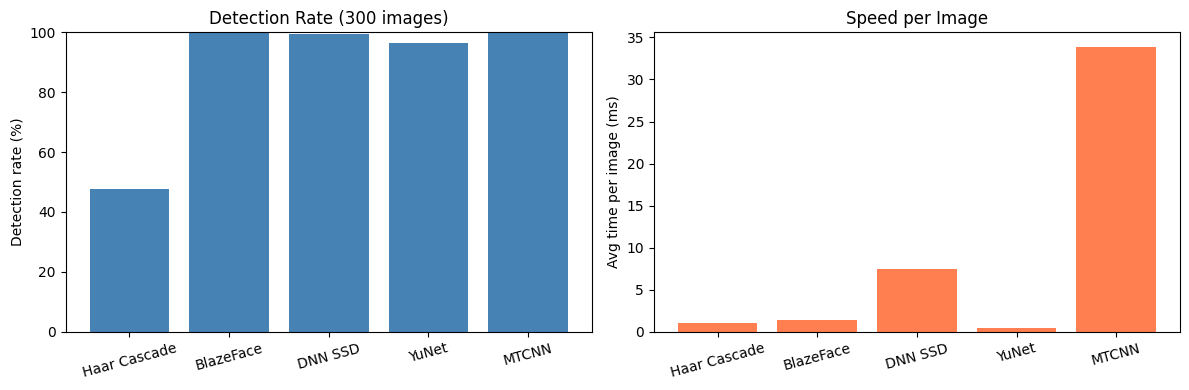

In [11]:
names  = list(results.keys())
rates  = [results[n]["detected"] / len(sample) * 100 for n in names]
times  = [np.mean(results[n]["times"]) * 1000 for n in names]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(names, rates, color="steelblue")
ax1.set_ylabel("Detection rate (%)")
ax1.set_title("Detection Rate (300 images)")
ax1.set_ylim(0, 100)
ax1.tick_params(axis="x", rotation=15)
ax2.bar(names, times, color="coral")
ax2.set_ylabel("Avg time per image (ms)")
ax2.set_title("Speed per Image")
ax2.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## 5 - Analysis

Clearly haar cascade is not up-to-standard for the project here. It should be noted that most of these models are performing incredibly well because the context of the dataset matters. 

This dataset contains very favourable testing conditions for the model, and does not exactly translate to what is likely to be seen on their implementation within the actual system. 

This includes, but is not limited to: variations in facial posing, difficult (realistic) lighting, distant faces.

All of the dataset is fairly front on and easy to do well at. 

The clear insight however, is on inference speed and accuracy generally. 

We can see that haar cascade fails on easy data, and thus, it can be generalised to say that any of these models would perform better than haar cascade. 

The time for inference for each is also important, and raises a clear tradeoff. 

Since the system is to be deployed on a laptop, and several other enhancements can enrich the accuracy, it makes the most sense to choose to use YuNet, since the inference time here is half the time of haar cascade. 

TL:DR: Using evaluation (limited, but still informative) has allowed us to understand the tradeoffs between potential facial detection backbones, and which is better to use within the system. In this case, we will be now shifting from haar cascade to YuNet after finding that it can 2x the accuracy and half the computation latency.